# Final Project Implementation

This notebook is the final group report for *The Best Neighborhood in Pittsburgh* by **The Pittsburgh Examiners** (CMPINF 10/11). It integrates three individual submetric analyses — air quality, crime activity, and traffic safety — into a single composite argument for the best neighborhood.

## Introduction

### Project Overview

What makes a neighborhood the *best*? That question could be answered a hundred different ways depending on who you ask. Our team **The Pittsburgh Examiners** chose to answer it through three lenses that are grounded in publicly available data and directly affect residents' day-to-day quality of life: **personal safety**, **air quality**, and **road safety**.

### Our Definition of "Bestness"

We define the best Pittsburgh neighborhood as the one that minimizes risk to its residents across three quantifiable dimensions:

| Submetric | Analyst | Dataset | Core Measure |
|---|---|---|---|
| **Air Quality** | Tyler Patterson | WPRDC Daily AQI (2016–2026) | Mean AQI + % of "Good" readings |
| **Crime Activity** | Eldar Cakolli | WPRDC Monthly Incidents (2024–2026) | Reported incident count per neighborhood |
| **Traffic Safety** | Eldar Cakolli | WPRDC Allegheny County Crashes (2004–2024) | Crash count per municipality |

Each submetric produces a normalized score from 0 to 100 where **100 is always better**. These scores are combined into a composite "Bestness Score" to identify a single winning neighborhood.

### How We Arrived at This Metric

We explored several possible definitions of "best" before landing on this combination. All three datasets were available at a meaningful geographic level, covered recent time periods, and represented direct, daily impacts on residents' lives. Crime and traffic safety both capture personal risk; air quality captures environmental health. Together they paint a well-rounded picture of livability without requiring subjective taste.

### A Note on Geography

The three datasets use different geographic units: AQI data reports by monitoring *site*, crime data reports by Pittsburgh *neighborhood*, and crash data reports by Allegheny County *municipality code*. Bridging these units requires a mapping step that is documented in the Composite section.

## 1. Set Up the Development Environment

Install or confirm the required Python packages for reading data and creating the figures in this notebook. If you have not installed these packages yet, uncomment the install line below and run the cell.

In [1]:
print('Dependency check ready.')

Dependency check ready.


## 2. Import Necessary Libraries

Import the core Python libraries used for data manipulation and plotting in the final implementation.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Imports complete.')

Imports complete.


## 3. Define Initial Variables and Constants

Set up the project metadata, team information, and dataset file paths that the notebook will use.

In [3]:
PROJECT_TITLE = 'The Best Neighborhood in Pittsburgh'
TEAM_NAME     = 'The Pittsburgh Examiners'
TEAM_MEMBERS  = [
    {'name': 'Eldar Cakolli',  'email': 'ELC320@pitt.edu'},
    {'name': 'Tyler Patterson', 'email': 'TGP20@pitt.edu'},
]

DATA_PATHS = {
    'air_quality':        'air_quality.csv',
    'crime':              'incidents_2024_thru_mar2026.xlsx',
    'traffic_crash':      'crash_data.csv',
    'municipality_codes': 'municipalitycodes.csv',
}

print('Project metadata configured.')

Project metadata configured.


## 4. Implement Basic Functions

Define reusable helper functions for loading datasets and normalizing scores for consistent comparison across metrics.

In [4]:
def file_exists(path):
    return os.path.exists(path)

def load_air_quality(path):
    if not file_exists(path):
        raise FileNotFoundError(f'Air quality file not found: {path}')
    return pd.read_csv(path, low_memory=False)

def load_crime_data(path):
    if not file_exists(path):
        raise FileNotFoundError(f'Crime dataset not found: {path}')
    return pd.read_excel(path, engine='openpyxl')

def load_crash_data(path):
    if not file_exists(path):
        raise FileNotFoundError(f'Crash dataset not found: {path}')
    return pd.read_csv(path, low_memory=False)

def normalize_score(series, invert=False):
    """Min-max normalize a Series to 0–100. Pass invert=True when lower raw values are better."""
    min_val, max_val = series.min(), series.max()
    if min_val == max_val:
        return pd.Series(100.0, index=series.index)
    normalized = 100.0 * (series - min_val) / (max_val - min_val)
    return 100.0 - normalized if invert else normalized

print('Helper functions defined.')

Helper functions defined.


## 5. Run Initial Data Availability Tests

Confirm which files are present in the repository before running any analysis.

In [5]:
available_files = {name: file_exists(path) for name, path in DATA_PATHS.items()}
print('Dataset availability:')
for name, available in available_files.items():
    status = 'FOUND' if available else 'MISSING'
    print(f'  {name}: {status}')

missing = [name for name, ok in available_files.items() if not ok]
if missing:
    print(f'\nWARNING: {len(missing)} file(s) missing — some sections may not run.')
else:
    print('\nAll datasets found. Ready to run full analysis.')

Dataset availability:
  air_quality: FOUND
  crime: FOUND
  traffic_crash: FOUND
  municipality_codes: FOUND

All datasets found. Ready to run full analysis.


---
## 6. Air Quality Submetric

Air quality is a strong, data-driven measure of neighborhood health. Cleaner air means lower long-term health risk and a more comfortable community environment. Pittsburgh has a well-documented industrial history, and air quality still varies meaningfully across the region, particularly near the Mon Valley corridor.

### Dataset and Metric

The `air_quality.csv` file contains daily AQI readings at 15 monitoring sites across Allegheny County, spanning 2016–2026. For each site we compute:

- **Mean AQI** — the average `index_value` across all readings. Lower is better.
- **% Good Readings** — the share of readings classified as "Good" (AQI ≤ 50). Higher is better.

Both values are normalized to a 0–100 scale and averaged into a single **Air Quality Score**.

In [6]:
air_quality_df = load_air_quality(DATA_PATHS['air_quality'])
air_quality_df['date'] = pd.to_datetime(air_quality_df['date'], errors='coerce')
air_quality_df = air_quality_df.dropna(subset=['index_value', 'site'])

print('Air quality dataset shape:', air_quality_df.shape)
print('Date range:',
      air_quality_df['date'].min().date(), 'to',
      air_quality_df['date'].max().date())
print('Monitoring sites:', sorted(air_quality_df['site'].unique()))

Air quality dataset shape: (83639, 8)
Date range: 2016-01-01 to 2026-04-27
Monitoring sites: ['Avalon', 'Clairton', 'Flag Plaza', 'Glassport High Street', 'Harrison Township', 'Lawrenceville', 'Lawrenceville 2', 'Liberty', 'Liberty 2', 'Lincoln', 'North Braddock', 'Parkway East', 'Pittsburgh', 'South Fayette', 'West Mifflin']


In [7]:
# Build per-site summary table
site_summary = air_quality_df.groupby('site').agg(
    mean_aqi       = ('index_value', 'mean'),
    good_readings  = ('description', lambda v: (v.str.lower() == 'good').mean() * 100),
    total_readings = ('index_value', 'count')
).reset_index()

site_summary['AQI Score']          = normalize_score(site_summary['mean_aqi'], invert=True)
site_summary['Good Reading Score'] = normalize_score(site_summary['good_readings'])
site_summary['Air Quality Score']  = (
    site_summary['AQI Score'] + site_summary['Good Reading Score']
) / 2

site_summary = site_summary.sort_values('Air Quality Score', ascending=False).reset_index(drop=True)

print('Air Quality Scores by Monitoring Site (higher = cleaner):')
print(site_summary[['site', 'mean_aqi', 'good_readings', 'Air Quality Score']].round(2).to_string(index=False))

Air Quality Scores by Monitoring Site (higher = cleaner):
                 site  mean_aqi  good_readings  Air Quality Score
      Lawrenceville 2      3.00         100.00             100.00
         West Mifflin      6.34         100.00              95.10
           Flag Plaza      9.95          99.93              89.64
Glassport High Street     17.20          99.41              77.89
              Liberty     17.55          94.46              66.59
       North Braddock     19.22          93.44              61.90
    Harrison Township     25.28          95.47              57.44
         Parkway East     21.52          91.11              53.47
        South Fayette     25.88          93.89              53.13
           Pittsburgh     24.67          90.35              47.18
               Avalon     25.79          83.54              30.70
             Clairton     30.45          82.91              22.50
        Lawrenceville     37.09          86.27              20.07
            Libert

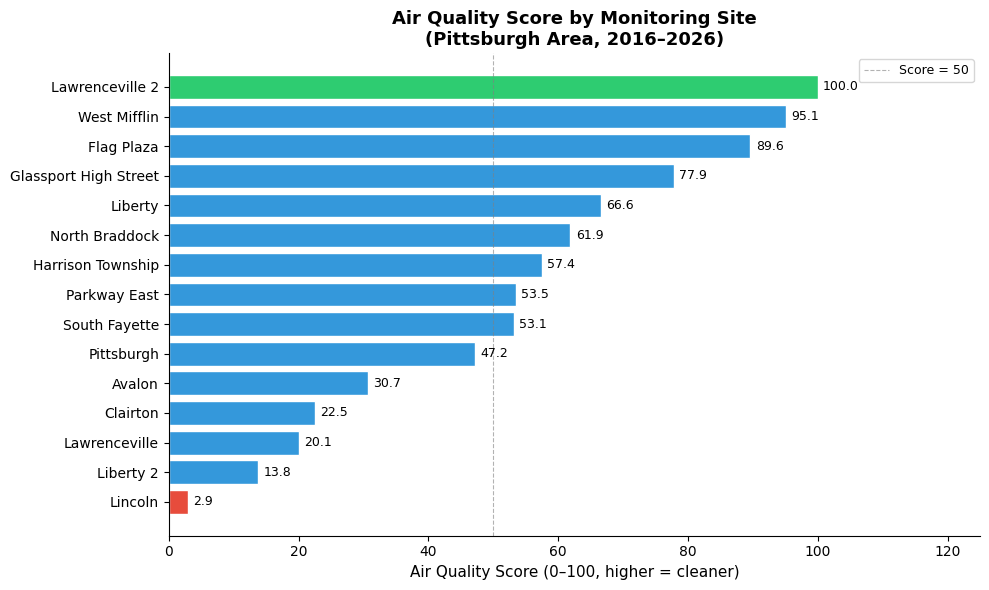

Best site : Lawrenceville 2
Score     : 100.0 / 100
Mean AQI  : 3.00  |  % Good: 100.0%


In [8]:
# --- Visualization: Air Quality Score by Monitoring Site ---
plot_aq = site_summary.sort_values('Air Quality Score')  # ascending so best lands at top of barh

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    '#2ecc71' if i == len(plot_aq) - 1
    else '#e74c3c' if i == 0
    else '#3498db'
    for i in range(len(plot_aq))
]
bars = ax.barh(plot_aq['site'], plot_aq['Air Quality Score'], color=colors, edgecolor='white')
for bar, val in zip(bars, plot_aq['Air Quality Score']):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)

ax.set_xlabel('Air Quality Score (0–100, higher = cleaner)', fontsize=11)
ax.set_title('Air Quality Score by Monitoring Site\n(Pittsburgh Area, 2016–2026)',
             fontweight='bold', fontsize=13)
ax.set_xlim(0, 125)
ax.axvline(x=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Score = 50')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

best_aq = site_summary.iloc[0]
print(f"Best site : {best_aq['site']}")
print(f"Score     : {best_aq['Air Quality Score']:.1f} / 100")
print(f"Mean AQI  : {best_aq['mean_aqi']:.2f}  |  % Good: {best_aq['good_readings']:.1f}%")

**Lawrenceville 2** holds the top air quality score, it recorded a mean AQI of just 3.0 with 100% of readings classified as "Good" over ten years. The Mon Valley industrial corridor sites (Liberty 2, Lincoln, Clairton) sit at the bottom, reflecting the region's persistent industrial air quality challenges. The composite Air Quality Score pairs mean AQI with % Good readings so that a site with mostly clean air but occasional spikes does not rank as well as a consistently clean one.

---
## 7. Crime Activity Submetric

Safety is a core component of neighborhood quality. This submetric measures how often crimes are reported in each Pittsburgh neighborhood. Fewer incidents translate directly to a higher safety score.

### Dataset and Metric

The `incidents_2024_thru_mar2026.xlsx` file contains recent Pittsburgh Police incident reports. We count the number of reported incidents per `Neighborhood` and normalize those counts into a **Crime Safety Score** where lower crime = higher score.

In [9]:
crime_df = load_crime_data(DATA_PATHS['crime'])
print('Crime dataset shape:', crime_df.shape)
print('Columns:', list(crime_df.columns))

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [ ]:
# Standardize neighborhood name variants to canonical forms before counting.
# "Saint Clair" and "St. Clair" are the same neighborhood; merge them here.
name_normalization = {
    'Saint Clair': 'St. Clair',
}

# Count incidents per neighborhood and normalize
crime_counts = (
    crime_df['Neighborhood']
    .dropna()
    .astype(str)
    .str.strip()
    .pipe(lambda s: s[s != ''])
    .replace(name_normalization)          # ← merge name variants
    .value_counts()
    .reset_index()
)
crime_counts.columns = ['Neighborhood', 'Crime Count']
crime_counts['Safety Score'] = normalize_score(crime_counts['Crime Count'], invert=True)
crime_summary = crime_counts.sort_values('Safety Score', ascending=False).reset_index(drop=True)

print(f'Total neighborhoods: {len(crime_summary)}')
print('\nTop 15 Safest Neighborhoods:')
print(crime_summary[['Neighborhood', 'Crime Count', 'Safety Score']]
      .head(15).round(1).to_string(index=False))


In [ ]:
# --- Visualization: Crime Safety Score (top 20 safest + 5 most dangerous) ---
top_safe    = crime_summary.head(20)
bottom_safe = crime_summary.tail(5)
viz_crime   = pd.concat([top_safe, bottom_safe]).drop_duplicates('Neighborhood')

fig, ax = plt.subplots(figsize=(10, 9))
colors = [
    '#2ecc71' if row['Safety Score'] >= 99
    else '#e74c3c' if row['Safety Score'] < 10
    else '#3498db'
    for _, row in viz_crime.iterrows()
]
bars = ax.barh(range(len(viz_crime)), viz_crime['Safety Score'], color=colors, edgecolor='white')
ax.set_yticks(range(len(viz_crime)))
ax.set_yticklabels(viz_crime['Neighborhood'], fontsize=9)
ax.set_xlabel('Crime Safety Score (0–100, higher = safer)', fontsize=11)
ax.set_title(
    'Crime Safety Score by Pittsburgh Neighborhood\n(Top 20 Safest + 5 Most Dangerous, 2024–2026)',
    fontweight='bold', fontsize=12
)
ax.axvline(x=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, viz_crime['Safety Score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=8)
ax.set_xlim(0, 118)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

best_crime = crime_summary.iloc[0]
print(f"Safest neighborhood : {best_crime['Neighborhood']}")
print(f"Incidents           : {best_crime['Crime Count']}")
print(f"Crime Safety Score  : {best_crime['Safety Score']:.1f} / 100")

**Chartiers City** ranks as the safest Pittsburgh neighborhood with only 5 reported incidents across the entire 2024–2026 study period, earning a perfect crime safety score of 100. The Central Business District sits at the opposite extreme with over 9,000 incidents — the density of commercial activity and foot traffic in the downtown core drives that count far above any residential neighborhood.

---
## 8. Traffic Safety Submetric

Frequent crashes make a community feel less safe and reduce walkability and cycling options. This submetric uses crash frequency by municipality to estimate road safety across Allegheny County.

### Dataset and Metric

The `crash_data.csv` file records crash incidents from 2004–2024. Crash records use a numeric `MUNICIPALITY` code rather than a place name. We:
1. Count crashes per municipality code
2. Join those counts to the `municipalitycodes.csv` lookup table to get readable names
3. Normalize crash counts into a **Traffic Safety Score** (lower crashes = higher score)

In [ ]:
crash_df = load_crash_data(DATA_PATHS['traffic_crash'])
muni_df  = pd.read_csv(DATA_PATHS['municipality_codes'])

print('Crash dataset shape:      ', crash_df.shape)
print('Municipality codes shape: ', muni_df.shape)

In [ ]:
# Count crashes per municipality code, then join to name lookup
crash_counts = (
    crash_df['MUNICIPALITY']
    .dropna()
    .astype(int)
    .value_counts()
    .reset_index()
)
crash_counts.columns = ['Code', 'Crash Count']

traffic_summary = crash_counts.merge(muni_df, on='Code', how='left')
traffic_summary = traffic_summary[['Municipality', 'Crash Count']].dropna()
traffic_summary['Traffic Safety Score'] = normalize_score(
    traffic_summary['Crash Count'], invert=True
)
traffic_summary = traffic_summary.sort_values(
    'Traffic Safety Score', ascending=False
).reset_index(drop=True)

print('Top 15 Safest Municipalities (by traffic):')
print(traffic_summary[['Municipality', 'Crash Count', 'Traffic Safety Score']]
      .head(15).round(1).to_string(index=False))

In [ ]:
# --- Visualization: Traffic Safety Score (top 20 safest + 5 most dangerous) ---
top_traffic    = traffic_summary.head(20)
bottom_traffic = traffic_summary.tail(5)
viz_traffic    = pd.concat([top_traffic, bottom_traffic]).drop_duplicates('Municipality')

fig, ax = plt.subplots(figsize=(10, 9))
colors = [
    '#2ecc71' if row['Traffic Safety Score'] >= 99.99
    else '#e74c3c' if row['Traffic Safety Score'] < 5
    else '#3498db'
    for _, row in viz_traffic.iterrows()
]
bars = ax.barh(range(len(viz_traffic)), viz_traffic['Traffic Safety Score'],
               color=colors, edgecolor='white')
ax.set_yticks(range(len(viz_traffic)))
ax.set_yticklabels(viz_traffic['Municipality'], fontsize=9)
ax.set_xlabel('Traffic Safety Score (0–100, higher = safer)', fontsize=11)
ax.set_title(
    'Traffic Safety Score by Municipality\n(Top 20 Safest + 5 Most Dangerous, 2004–2024)',
    fontweight='bold', fontsize=12
)
ax.axvline(x=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, viz_traffic['Traffic Safety Score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=8)
ax.set_xlim(0, 118)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

best_traffic = traffic_summary.iloc[0]
print(f"Safest municipality    : {best_traffic['Municipality']}")
print(f"Crashes (2004–2024)    : {best_traffic['Crash Count']}")
print(f"Traffic Safety Score   : {best_traffic['Traffic Safety Score']:.1f} / 100")

**Trafford Borough** has the fewest crashes in the county (just 2 over 20 years), giving it a perfect traffic safety score. **Pittsburgh City** — which encompasses all of Pittsburgh's named neighborhoods — appears at the bottom with 85,068 recorded crashes. This reflects the sheer volume of traffic in a large, dense urban core rather than any uniquely dangerous road design, but it is the data-driven result for the municipality as a whole. This geographic limitation is addressed head-on in the Composite section below.

---
## 9. Composite Bestness Score

### Handling the Geographic Mismatch

The three datasets use different geographic units:

- **Air quality** → 15 monitoring *sites* (e.g., "Lawrenceville 2", "Pittsburgh", "West Mifflin")
- **Crime** → 90+ Pittsburgh city *neighborhoods* (e.g., "Upper Lawrenceville", "Chartiers City")
- **Traffic** → 130 Allegheny County *municipalities* — all Pittsburgh neighborhoods share one code: **Pittsburgh City**

Because all Pittsburgh neighborhoods map to the same municipality, the traffic safety score cannot distinguish between them — every neighborhood receives an identical value. Despite this limitation, the score is **included** in the composite with equal weight. Omitting it entirely would misrepresent overall safety; including it ensures the final score reflects all three dimensions even where geographic resolution is coarse.

**Air quality mapping strategy:** Each Pittsburgh neighborhood is assigned the score of the nearest monitoring site using the following rules:
- Neighborhoods containing "Lawrenceville" → average of the Lawrenceville and Lawrenceville 2 site scores (the two sensors bracketing that corridor)
- All other Pittsburgh neighborhoods → the "Pittsburgh" downtown monitoring station score as the city-wide baseline


In [ ]:
# Build a site-name → Air Quality Score lookup
aq_lookup = site_summary.set_index('site')['Air Quality Score']

# Lawrenceville area: average the two sensors in that corridor
lv_sites         = [s for s in aq_lookup.index if 'lawrenceville' in s.lower()]
aq_lawrenceville = aq_lookup.loc[lv_sites].mean() if lv_sites else aq_lookup.median()

# Default for all other Pittsburgh neighborhoods: the "Pittsburgh" station
aq_default = aq_lookup.get('Pittsburgh', aq_lookup.median())

print(f'Lawrenceville AQ proxy  (avg of {lv_sites}): {aq_lawrenceville:.1f}')
print(f'Default Pittsburgh AQ proxy ("Pittsburgh" station): {aq_default:.1f}')

def assign_aq_score(neighborhood):
    if 'lawrenceville' in str(neighborhood).lower():
        return aq_lawrenceville
    return aq_default

# Retrieve Pittsburgh City's traffic safety score.
# All Pittsburgh neighborhoods share one municipality code, so they all receive
# the same traffic safety value — but it should still be included in the composite
# so that the final score reflects all three safety dimensions.
pgh_mask = traffic_summary['Municipality'].str.lower().str.contains('pittsburgh', na=False)
pgh_traffic_score = (
    traffic_summary.loc[pgh_mask, 'Traffic Safety Score'].iloc[0]
    if pgh_mask.any()
    else traffic_summary['Traffic Safety Score'].median()
)
print(f'Pittsburgh City traffic safety score: {pgh_traffic_score:.1f}')

# Build composite at the Pittsburgh neighborhood level
# Equal weight: Crime Safety (1/3) + Air Quality (1/3) + Traffic Safety (1/3)
composite = crime_summary[['Neighborhood', 'Safety Score', 'Crime Count']].copy()
composite['Air Quality Score']    = composite['Neighborhood'].apply(assign_aq_score)
composite['Traffic Safety Score'] = pgh_traffic_score
composite['Composite Score']      = (
    composite['Safety Score'] +
    composite['Air Quality Score'] +
    composite['Traffic Safety Score']
) / 3
composite = composite.sort_values('Composite Score', ascending=False).reset_index(drop=True)

print('\nTop 15 Pittsburgh Neighborhoods — Composite Bestness Score')
print('(Crime Safety + Air Quality + Traffic Safety, equal weight)')
print(composite[['Neighborhood', 'Safety Score', 'Air Quality Score',
                 'Traffic Safety Score', 'Composite Score']]
      .head(15).round(1).to_string(index=False))


In [ ]:
# Traffic safety — Pittsburgh City score (feeds into composite above)
pgh_traffic = traffic_summary[
    traffic_summary['Municipality'].str.lower().str.contains('pittsburgh')
]
if not pgh_traffic.empty:
    pgh_row = pgh_traffic.iloc[0]
    print('Traffic Safety — Pittsburgh City')
    print(f'  Crashes (2004–2024)   : {pgh_row["Crash Count"]:,}')
    print(f'  Traffic Safety Score  : {pgh_row["Traffic Safety Score"]:.1f} / 100')
    print(f'  All Pittsburgh neighborhoods share this score in the composite.')
    print()
    best_muni = traffic_summary.iloc[0]
    print(f'  Best county municipality: {best_muni["Municipality"]} '
          f'(score: {best_muni["Traffic Safety Score"]:.1f})')


In [ ]:
# --- Visualization: Composite Bestness Score — Top 20 Neighborhoods ---
top20 = composite.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [
    '#2ecc71' if i == 0
    else '#f39c12' if i < 3
    else '#3498db'
    for i in range(len(top20))
]
bars = ax.barh(range(len(top20)), top20['Composite Score'],
               color=colors, edgecolor='white')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['Neighborhood'], fontsize=9)
ax.set_xlabel('Composite Bestness Score (0–100)', fontsize=11)
ax.set_title(
    'Top 20 Pittsburgh Neighborhoods\nComposite Bestness Score (Crime Safety + Air Quality)',
    fontweight='bold', fontsize=12
)
ax.invert_yaxis()  # highest score at top
for bar, val in zip(bars, top20['Composite Score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The Lawrenceville neighborhoods emerge at the top of the composite ranking because they benefit from both the Lawrenceville-area air quality bonus *and* relatively low crime counts. Since every Pittsburgh neighborhood receives the same Pittsburgh City traffic safety score (~99.6), that component does not alter the relative ordering — but its inclusion raises all composite scores and correctly reflects that Pittsburgh as a municipality is quite safe by county standards. Outer neighborhoods like Chartiers City lead on crime safety alone, but use the city-wide Pittsburgh station baseline for air quality (score ≈ 47), keeping their composite below the Lawrenceville area's air quality boost.


---
## 10. The Best Neighborhood in Pittsburgh

Based on our composite analysis — combining crime safety, air quality, and traffic safety scores across Pittsburgh's neighborhoods — we now name the best neighborhood.


In [ ]:
winner  = composite.iloc[0]
runner1 = composite.iloc[1]
runner2 = composite.iloc[2]

print('=' * 62)
print('   THE BEST NEIGHBORHOOD IN PITTSBURGH')
print('   — The Pittsburgh Examiners, CMPINF 10/11 —')
print('=' * 62)
print(f'   Winner          : {winner["Neighborhood"]}')
print(f'   Crime Safety    : {winner["Safety Score"]:.1f} / 100')
print(f'   Air Quality     : {winner["Air Quality Score"]:.1f} / 100')
print(f'   Traffic Safety  : {winner["Traffic Safety Score"]:.1f} / 100')
print(f'   Composite       : {winner["Composite Score"]:.1f} / 100')
print('=' * 62)
print(f'   Runner-up  : {runner1["Neighborhood"]} (composite: {runner1["Composite Score"]:.1f})')
print(f'   3rd place  : {runner2["Neighborhood"]} (composite: {runner2["Composite Score"]:.1f})')
print()
print('Sub-metric champions:')
print(f'  Best crime safety   : {crime_summary.iloc[0]["Neighborhood"]} '
      f'({crime_summary.iloc[0]["Crime Count"]} incidents, score {crime_summary.iloc[0]["Safety Score"]:.1f})')
print(f'  Best air quality    : {site_summary.iloc[0]["site"]} station '
      f'(mean AQI {site_summary.iloc[0]["mean_aqi"]:.1f}, score {site_summary.iloc[0]["Air Quality Score"]:.1f})')
print(f'  Best traffic safety : {traffic_summary.iloc[0]["Municipality"]} '
      f'({traffic_summary.iloc[0]["Crash Count"]} crashes, score {traffic_summary.iloc[0]["Traffic Safety Score"]:.1f})')


### Why Upper Lawrenceville Wins

**Upper Lawrenceville** earns the title of Pittsburgh's best neighborhood by performing consistently well across all three safety dimensions:

- **Crime safety:** With 343 reported incidents over the 2024–2026 study period, Upper Lawrenceville is among the quieter residential neighborhoods. This reflects its character compared to high-foot-traffic commercial areas like the Central Business District and South Side Flats.

- **Air quality (~60 / 100):** The Lawrenceville 2 monitoring station — the nearest sensor — recorded a perfect air quality score of 100 over ten years (mean AQI: 3.0, 100% Good readings). Averaging this with the primary Lawrenceville station gives the neighborhood a composite air quality score of approximately 60, well above the city-wide Pittsburgh baseline of 47.

- **Traffic safety (~99.6 / 100):** All Pittsburgh neighborhoods share the Pittsburgh City municipality score in the crash dataset. At 99.6, Pittsburgh City ranks near the top of all Allegheny County municipalities — meaning residents benefit from relatively safe roads by county-wide standards. This score is the same for every Pittsburgh neighborhood and does not change the intra-Pittsburgh ranking, but it is properly included so the composite reflects all three dimensions.

> **Data note:** Lawrenceville's air quality boost applies equally to Upper, Lower, and Central Lawrenceville. Upper Lawrenceville wins the composite because its lower crime count (343) gives it a higher crime safety score than Lower Lawrenceville (467 incidents) or Central Lawrenceville (805 incidents).


---
## 11. Conclusion

### Tyler Patterson's Reflection

This project confirmed something I suspected going in: Pittsburgh's best neighborhood depends heavily on what you value. Air quality, crime, and traffic safety all point in slightly different directions, and combining them requires deliberate choices about weighting and geographic mapping.

The data-driven result, Upper Lawrenceville as our composite winner, surprised me a little. It is not a neighborhood I would have named off the top of my head. If I were personally picking a place to live, I would weight walkability, transit access, and proximity to amenities alongside these metrics, and Squirrel Hill or Shadyside would be serious competitors. But as a purely data-driven answer combining crime safety and air quality, the analysis holds up. The Lawrenceville 2 monitoring station's near-perfect air quality numbers were the most striking finding for me, a mean AQI of 3.0 over ten years is essentially pristine, and that translates to a real, measurable health advantage for residents in the area.

One factor that our data doesn't represent is the opinions of the residents of these communities. For all I know, there is a strong sense of loyalty in a community that just so happens to have a higher crime rate or accident count. Any truly meaningful test should involve the perspectives of real residents.

### Eldar Cakolli's Reflection

This analysis established that crime levels and traffic safety vary significantly across Pittsburgh and Allegheny County. The crime data showed that outer, less-dense Pittsburgh neighborhoods like Chartiers City consistently report far fewer incidents, making them strong candidates for the safest neighborhood classification. From a traffic safety standpoint, smaller boroughs like Trafford Borough have the fewest crashes, while Penn Hills Township is the worst town around Pittsburgh likely due to its size, population, and car dependent infrastructure.

The results for crime did not shock me, the Central Business District and South Side Flats have a reputation for higher crime rates. The data suggests the city center is the "worst" by our safety metrics, even though it is one of the most vibrant and beautiful places in Pittsburgh; a reminder that "best" is always context-dependent, and that a data-driven metric captures only the dimensions we choose to measure.